# Travel App Customer & Booking Analytics

**Tools:** Pandas, NumPy, Matplotlib

This notebook follows the assignment in the requested order: dataset understanding, data-quality checking, cleaning, statistical analysis, customer/destination/travel/booking analysis, loyalty and app-usage analysis, visualization, and final business conclusions.

> **Important:** The actual dataset column names used here are based on the dataset inspected so far. In particular, `Booking_Amount` and `Customer_Likes` are converted to numeric because they were initially stored as categorical/text columns.

## 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load the Dataset

In [3]:
df = pd.read_csv("travelapp_dataset.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (100000, 21)


## 3. Dataset Understanding — Questions 1–14

In [4]:
# Q2. First 10 records
print("First 10 Records:")
display(df.head(10))

# Q3. Last 10 records
print("Last 10 Records:")
display(df.tail(10))

# Q4. Number of rows and columns
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

# Q5. All column names
print("\nColumn Names:")
print(df.columns.tolist())

# Q6. Data types
print("\nData Types:")
display(df.dtypes.to_frame("Data Type"))

# Q7. Dataset structure
print("\nDataset Information:")
df.info()

# Q8. Statistical summary
print("\nStatistical Summary:")
display(df.describe(include="all"))

# Q9. Numerical and categorical columns as originally loaded
numeric_cols_original = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols_original = df.select_dtypes(include=["object", "string", "category"]).columns.tolist()

print("\nNumerical Columns:")
print(numeric_cols_original)

print("\nCategorical Columns:")
print(categorical_cols_original)

# Q10. Unique customers
print("\nQ10. Unique Customers:", df["Customer_ID"].nunique())

# Q11. Unique destinations
print("Q11. Unique Destinations:", df["Destination"].nunique())

# Q12. Unique travel types
print("Q12. Unique Travel Types:", df["Travel_Type"].nunique())

# Q13. Unique package types
print("Q13. Unique Package Types:", df["Package_Type"].nunique())

# Q14. Unique transport modes
print("Q14. Unique Transport Modes:", df["Transport_Mode"].nunique())

First 10 Records:


,Customer_ID,Customer_Name,Age,Gender,City,Destination,Travel_Type,Package_Type,Booking_Count,Booking_Amount,Trip_Duration,Customer_Rating,Customer_Likes,Reviews,Hotel_Rating,Transport_Mode,Payment_Method,Booking_Status,Cancellation_Count,App_Usage,Loyalty_Member
0,C10001,Customer_1,19.00,Female,Kochi,Singapore,Business,Luxury,5,438148,11,4.80,1071,0.00,4.40,Train,Cash,Completed,1,High,Yes
1,C10002,Customer_2,35.00,Female,Kolkata,Thailand,Couple,Premium,1,234723,10,3.10,995,3.00,2.90,Flight,UPI,Completed,1,High,No
2,C10003,Customer_3,49.00,Male,Delhi,Kashmir,Friends,Standard,4,30661,4,3.00,1570,7.00,2.90,Train,Cash,Completed,0,Medium,Yes
3,C10004,Customer_4,18.00,Female,Chennai,Hyderabad,Business,Budget,5,73632,12,2.70,2582,25.00,3.10,Train,Cash,Completed,1,Medium,No
4,C10005,Customer_5,51.00,Female,Madurai,Bali,Friends,Premium,1,254518,12,3.10,1139,4.00,3.40,Train,Debit Card,Completed,0,Medium,No
5,C10006,Customer_6,62.00,Female,Salem,Jaipur,Couple,Budget,6,4248,1,4.60,2387,6.00,4.80,Flight,Net Banking,Completed,2,Medium,No
6,C10007,Customer_7,18.00,Female,Coimbatore,Jaipur,Friends,Luxury,3,39116,1,4.90,3568,0.00,4.00,Car,Credit Card,Completed,1,Low,Yes
7,C10008,Customer_8,46.00,Female,Hyderabad,Munnar,Couple,Standard,5,158931,14,3.70,4383,8.00,4.20,Flight,Credit Card,Completed,3,Low,No
8,C10009,Customer_9,31.00,Male,Kolkata,Singapore,Business,Budget,5,24941,4,4.70,2983,11.00,3.10,Flight,Debit Card,Completed,0,Low,Yes
9,C10010,Customer_10,48.00,Male,Mumbai,Mumbai,Business,Premium,8,276197,14,4.40,891,15.00,3.90,Bus,UPI,Completed,1,High,Yes


Last 10 Records:


,Customer_ID,Customer_Name,Age,Gender,City,Destination,Travel_Type,Package_Type,Booking_Count,Booking_Amount,Trip_Duration,Customer_Rating,Customer_Likes,Reviews,Hotel_Rating,Transport_Mode,Payment_Method,Booking_Status,Cancellation_Count,App_Usage,Loyalty_Member
99990,C109991,Customer_99991,29.00,Male,Kolkata,Jaipur,Couple,Standard,1,25929,3,4.60,4788,14.00,3.30,Car,Debit Card,Completed,0,High,Yes
99991,C109992,Customer_99992,49.00,Female,Trichy,Goa,Couple,Luxury,6,79267,2,2.70,3681,3.00,3.60,Flight,Credit Card,Completed,0,High,No
99992,C109993,Customer_99993,32.00,Male,Chennai,Kashmir,Friends,Budget,1,33551,6,2.90,98,23.00,2.60,Bus,Credit Card,Completed,3,High,No
99993,C109994,Customer_99994,46.00,Female,Madurai,Thailand,Friends,Budget,5,58163,9,4.50,1530,10.00,4.40,Flight,Net Banking,Completed,1,Medium,No
99994,C109995,Customer_99995,59.00,Female,Pune,Maldives,Solo,Standard,2,159783,13,4.00,1398,9.00,3.20,Flight,Cash,Completed,2,Low,No
99995,C109996,Customer_99996,38.00,Female,Bengaluru,Goa,Family,Premium,7,302387,13,3.70,4115,24.00,3.30,Car,Credit Card,Completed,2,Medium,No
99996,C109997,Customer_99997,38.00,Male,Nagercoil,Ooty,Couple,Premium,5,58543,4,3.20,2930,8.00,3.30,Flight,UPI,Completed,2,High,Yes
99997,C109998,Customer_99998,61.00,Female,Mumbai,Singapore,Solo,Standard,3,92793,8,2.60,4678,17.00,4.60,Flight,Debit Card,Completed,1,Medium,No
99998,C109999,Customer_99999,45.00,Female,Nagercoil,Manali,Business,Standard,3,105732,13,2.90,1757,14.00,4.20,Train,Cash,Completed,0,Medium,No
99999,C110000,Customer_100000,21.00,Female,Nagercoil,Mumbai,Solo,Premium,2,71011,4,4.30,3751,28.00,2.50,Train,Cash,Completed,0,Low,No


Number of Rows: 100000
Number of Columns: 21

Column Names:
['Customer_ID', 'Customer_Name', 'Age', 'Gender', 'City', 'Destination', 'Travel_Type', 'Package_Type', 'Booking_Count', 'Booking_Amount', 'Trip_Duration', 'Customer_Rating', 'Customer_Likes', 'Reviews', 'Hotel_Rating', 'Transport_Mode', 'Payment_Method', 'Booking_Status', 'Cancellation_Count', 'App_Usage', 'Loyalty_Member']

Data Types:


,Data Type
Customer_ID,str
Customer_Name,str
Age,float64
Gender,str
City,str
Destination,str
Travel_Type,str
Package_Type,str
Booking_Count,int64
Booking_Amount,str



Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 21 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Customer_ID         100000 non-null  str    
 1   Customer_Name       100000 non-null  str    
 2   Age                 99500 non-null   float64
 3   Gender              99700 non-null   str    
 4   City                99437 non-null   str    
 5   Destination         99383 non-null   str    
 6   Travel_Type         99547 non-null   str    
 7   Package_Type        100000 non-null  str    
 8   Booking_Count       100000 non-null  int64  
 9   Booking_Amount      99300 non-null   str    
 10  Trip_Duration       100000 non-null  int64  
 11  Customer_Rating     99500 non-null   float64
 12  Customer_Likes      99550 non-null   str    
 13  Reviews             99650 non-null   float64
 14  Hotel_Rating        99550 non-null   float64
 15  Transport_Mode      1000

,Customer_ID,Customer_Name,Age,Gender,City,Destination,Travel_Type,Package_Type,Booking_Count,Booking_Amount,Trip_Duration,Customer_Rating,Customer_Likes,Reviews,Hotel_Rating,Transport_Mode,Payment_Method,Booking_Status,Cancellation_Count,App_Usage,Loyalty_Member
count,100000,100000,"99,500.00",99700,99437,99383,99547,100000,"100,000.00",99300,"100,000.00","99,500.00",99550,"99,650.00","99,550.00",100000,99594,100000,"100,000.00",99650,100000
unique,100000,100000,NaN,2,19,22,6,4,NaN,80052,NaN,NaN,5360,NaN,NaN,4,6,3,NaN,3,2
top,C10001,Customer_1,NaN,Female,Bengaluru,Kashmir,Business,Standard,NaN,-500,NaN,NaN,2264,NaN,NaN,Flight,Cash,Completed,NaN,Medium,No
freq,1,1,NaN,50003,13723,6759,20110,40061,NaN,35,NaN,NaN,43,NaN,NaN,45040,20023,82001,NaN,45066,65177
mean,NaN,NaN,41.44,NaN,NaN,NaN,NaN,NaN,4.51,NaN,8.03,3.75,NaN,14.97,3.75,NaN,NaN,NaN,1.50,NaN,NaN
std,NaN,NaN,13.93,NaN,NaN,NaN,NaN,NaN,2.29,NaN,4.61,0.73,NaN,8.95,0.73,NaN,NaN,NaN,1.12,NaN,NaN
min,NaN,NaN,8.00,NaN,NaN,NaN,NaN,NaN,1.00,NaN,-2.00,-1.00,NaN,0.00,-2.00,NaN,NaN,NaN,0.00,NaN,NaN
25%,NaN,NaN,29.00,NaN,NaN,NaN,NaN,NaN,3.00,NaN,4.00,3.10,NaN,7.00,3.10,NaN,NaN,NaN,1.00,NaN,NaN
50%,NaN,NaN,41.00,NaN,NaN,NaN,NaN,NaN,5.00,NaN,8.00,3.70,NaN,15.00,3.80,NaN,NaN,NaN,2.00,NaN,NaN
75%,NaN,NaN,53.00,NaN,NaN,NaN,NaN,NaN,7.00,NaN,12.00,4.40,NaN,23.00,4.40,NaN,NaN,NaN,3.00,NaN,NaN



Numerical Columns:
['Age', 'Booking_Count', 'Trip_Duration', 'Customer_Rating', 'Reviews', 'Hotel_Rating', 'Cancellation_Count']

Categorical Columns:
['Customer_ID', 'Customer_Name', 'Gender', 'City', 'Destination', 'Travel_Type', 'Package_Type', 'Booking_Amount', 'Customer_Likes', 'Transport_Mode', 'Payment_Method', 'Booking_Status', 'App_Usage', 'Loyalty_Member']

Q10. Unique Customers: 100000
Q11. Unique Destinations: 22
Q12. Unique Travel Types: 6
Q13. Unique Package Types: 4
Q14. Unique Transport Modes: 4


## 4. Data Quality Checking — Questions 15–28

In [5]:
# Q15–17. Missing values and percentages
print("Missing Values:")
display(df.isna().sum().to_frame("Missing Count"))

missing_pct = (df.isna().sum() / len(df) * 100).round(2)
print("Missing Percentage:")
display(missing_pct.to_frame("Missing Percentage"))

# Q18–19. Duplicate records
duplicate_count = df.duplicated().sum()
print("Q18. Are duplicate records present?", duplicate_count > 0)
print("Q19. Number of duplicate records:", duplicate_count)

# Q20–21. Inconsistent City/Destination names
# Show values that differ only by spaces/case.
def show_inconsistent_values(series, label):
    temp = pd.DataFrame({
        "original": series.dropna().astype(str),
        "normalized": series.dropna().astype(str).str.strip().str.casefold()
    })
    grouped = temp.groupby("normalized")["original"].unique()
    inconsistent = grouped[grouped.apply(len) > 1]
    print(f"\n{label} inconsistent values:")
    if len(inconsistent) == 0:
        print("No case/whitespace inconsistencies detected.")
    else:
        for key, values in inconsistent.items():
            print(f"{key} -> {list(values)}")

show_inconsistent_values(df["City"], "City")
show_inconsistent_values(df["Destination"], "Destination")

# Q22. Unrealistic Age
print("\nQ22. Unrealistic Age values:")
display(df[(df["Age"] < 0) | (df["Age"] > 100)])

# Q23. Customer Rating outside 0–5
print("Q23. Customer Rating outside 0–5:")
display(df[(df["Customer_Rating"] < 0) | (df["Customer_Rating"] > 5)])

# Q24. Hotel Rating outside 0–5
print("Q24. Hotel Rating outside 0–5:")
display(df[(df["Hotel_Rating"] < 0) | (df["Hotel_Rating"] > 5)])

# Q25. Negative Booking Amount
# This will be checked after numeric conversion in the next cell.

# Q26. Invalid Trip Duration
print("Q26. Invalid Trip Duration:")
display(df[pd.to_numeric(df["Trip_Duration"], errors="coerce") <= 0])

# Q27. NA/N/A/unknown/blank values
unknown_values = {"NA", "N/A", "na", "n/a", "unknown", "Unknown", "UNKNOWN", "", " "}
print("\nQ27. NA/N/A/unknown/blank values:")
for col in df.columns:
    mask = df[col].astype("string").str.strip().isin(unknown_values)
    if mask.any():
        print(f"{col}: {mask.sum()}")

# Q28. Numeric columns stored as text
print("\nQ28. Columns expected to be numeric:")
expected_numeric = [
    "Age", "Booking_Count", "Trip_Duration", "Customer_Rating",
    "Reviews", "Hotel_Rating", "Cancellation_Count",
    "Booking_Amount", "Customer_Likes"
]

for col in expected_numeric:
    if col in df.columns:
        converted = pd.to_numeric(
            df[col].astype("string").str.replace(r"[₹$€,]", "", regex=True).str.strip(),
            errors="coerce"
        )
        non_numeric = df[col].notna() & converted.isna()
        print(f"{col}: {non_numeric.sum()} non-numeric/text values")

Missing Values:


,Missing Count
Customer_ID,0
Customer_Name,0
Age,500
Gender,300
City,563
Destination,617
Travel_Type,453
Package_Type,0
Booking_Count,0
Booking_Amount,700


Missing Percentage:


,Missing Percentage
Customer_ID,0.00
Customer_Name,0.00
Age,0.50
Gender,0.30
City,0.56
Destination,0.62
Travel_Type,0.45
Package_Type,0.00
Booking_Count,0.00
Booking_Amount,0.70


Q18. Are duplicate records present? False
Q19. Number of duplicate records: 0

City inconsistent values:
bengaluru -> ['Bengaluru', 'BENGALURU', 'bengaluru']
chennai -> ['Chennai', 'CHENNAI', 'chennai']

Destination inconsistent values:
dubai -> ['Dubai', 'DUBAI', 'dubai']
goa -> ['Goa', 'goa', 'GOA']
munnar -> ['Munnar', 'MUNNAR', 'munnar']

Q22. Unrealistic Age values:


...

Q24. Hotel Rating outside 0–5:


,Customer_ID,Customer_Name,Age,Gender,City,Destination,Travel_Type,Package_Type,Booking_Count,Booking_Amount,Trip_Duration,Customer_Rating,Customer_Likes,Reviews,Hotel_Rating,Transport_Mode,Payment_Method,Booking_Status,Cancellation_Count,App_Usage,Loyalty_Member
2625,C12626,Customer_2626,60.00,Male,Bengaluru,Munnar,Family,Standard,3,100322,9,3.20,2804,9.00,7.00,Flight,Credit Card,Completed,2,Medium,Yes
5798,C15799,Customer_5799,21.00,Female,Bengaluru,Bali,Solo,Standard,6,67671,7,4.40,3929,19.00,-2.00,Car,Net Banking,Completed,1,Medium,No
6899,C16900,Customer_6900,30.00,Male,Bengaluru,Singapore,Business,Budget,1,5962,1,3.00,4295,11.00,7.00,Flight,UPI,Completed,3,Medium,Yes
7634,C17635,Customer_7635,51.00,Female,Chennai,Thailand,Friends,Budget,2,42510,10,4.80,2559,24.00,7.00,Bus,Credit Card,Completed,3,Medium,No
8375,C18376,Customer_8376,41.00,Female,Mumbai,Delhi,Couple,Budget,2,90569,15,4.60,4281,21.00,6.00,Flight,Debit Card,Completed,3,Medium,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
93026,C103027,Customer_93027,65.00,Male,Salem,Bali,Couple,Premium,3,53108,3,4.10,4301,28.00,-2.00,Train,Cash,Completed,1,Medium,Yes
93173,C103174,Customer_93174,21.00,Male,Kochi,Kerala,Family,Standard,3,101190,13,4.10,1745,22.00,-2.00,Flight,Net Banking,Cancelled,0,High,Yes
94218,C104219,Customer_94219,50.00,Male,Madurai,Munnar,Family,Standard,1,38847,3,4.10,3857,30.00,-2.00,Flight,UPI,Completed,1,Medium,No
96131,C106132,Customer_96132,30.00,Male,Trichy,goa,Couple,Budget,2,80414,13,3.10,2324,26.00,-2.00,Flight,Credit Card,Completed,2,Medium,Yes


Q26. Invalid Trip Duration:


,Customer_ID,Customer_Name,Age,Gender,City,Destination,Travel_Type,Package_Type,Booking_Count,Booking_Amount,Trip_Duration,Customer_Rating,Customer_Likes,Reviews,Hotel_Rating,Transport_Mode,Payment_Method,Booking_Status,Cancellation_Count,App_Usage,Loyalty_Member
81,C10082,Customer_82,63.00,Male,Nagercoil,Goa,Couple,Standard,1,29623,-2,2.60,2218,11.00,5.00,Flight,Cash,Cancelled,2,Medium,Yes
5127,C15128,Customer_5128,62.00,Male,Bengaluru,Mumbai,Solo,Standard,1,109708,-2,4.10,2767,5.00,3.10,Car,UPI,Completed,1,Medium,No
5148,C15149,Customer_5149,53.00,Female,Bengaluru,Hyderabad,Friends,Standard,4,31120,-2,4.90,1941,12.00,2.90,Flight,UPI,Completed,1,Medium,No
6964,C16965,Customer_6965,30.00,Male,Nagercoil,Singapore,Couple,Standard,8,125119,0,4.00,1949,30.00,3.30,Car,Net Banking,Pending,2,High,No
8620,C18621,Customer_8621,56.00,Female,Nagercoil,Hyderabad,Family,Premium,3,143361,0,3.90,3957,0.00,2.80,Flight,UPI,Completed,1,High,No
9739,C19740,Customer_9740,51.00,Male,Mumbai,Dubai,Couple,Premium,3,179832,0,2.80,2729,3.00,4.40,Flight,Net Banking,Completed,1,Medium,Yes
9989,C19990,Customer_9990,36.00,Female,Pune,Goa,Business,Standard,6,97096,-2,4.50,2198,8.00,5.00,Flight,Debit Card,Completed,0,High,Yes
14369,C24370,Customer_14370,63.00,Female,Bengaluru,Hyderabad,Couple,Premium,2,105595,0,3.20,2733,21.00,2.70,Flight,Credit Card,Completed,3,High,Yes
15920,C25921,Customer_15921,38.00,Male,Salem,Kashmir,Family,Premium,3,178989,-2,2.80,1000,5.00,4.60,Flight,Cash,Completed,0,Medium,Yes
17029,C27030,Customer_17030,19.00,Male,Nagercoil,Hyderabad,Solo,Budget,7,5729,-2,3.50,3646,20.00,5.00,Flight,Cash,Completed,0,Low,Yes



Q27. NA/N/A/unknown/blank values:
City: 37
Destination: 31
Travel_Type: 46
Payment_Method: 43

Q28. Columns expected to be numeric:
Age: 0 non-numeric/text values
Booking_Count: 0 non-numeric/text values
Trip_Duration: 0 non-numeric/text values
Customer_Rating: 0 non-numeric/text values
Reviews: 0 non-numeric/text values
Hotel_Rating: 0 non-numeric/text values
Cancellation_Count: 0 non-numeric/text values
Booking_Amount: 0 non-numeric/text values
Customer_Likes: 0 non-numeric/text values


## 5. Data Cleaning — Questions 29–41

In [6]:
# Work on a copy so the original loaded data remains available.
df_clean = df.copy()

# Q39. Handle NA/N/A/unknown/blank values by converting them to NaN.
unknown_tokens = {
    "NA", "N/A", "na", "n/a", "unknown", "Unknown", "UNKNOWN", "", " "
}

for col in df_clean.select_dtypes(include=["object", "string"]).columns:
    cleaned_text = df_clean[col].astype("string").str.strip()
    df_clean.loc[cleaned_text.isin(unknown_tokens), col] = np.nan

# Q29. Standardize City values
df_clean["City"] = (
    df_clean["City"]
    .astype("string")
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
    .str.title()
)

# Q30. Standardize Destination values
df_clean["Destination"] = (
    df_clean["Destination"]
    .astype("string")
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
    .str.title()
)

# Q38. Convert numeric columns stored as text.
numeric_columns = [
    "Age",
    "Booking_Count",
    "Trip_Duration",
    "Customer_Rating",
    "Reviews",
    "Hotel_Rating",
    "Cancellation_Count",
    "Booking_Amount",
    "Customer_Likes"
]

for col in numeric_columns:
    if col in df_clean.columns:
        df_clean[col] = pd.to_numeric(
            df_clean[col].astype("string")
            .str.replace(r"[₹$€,]", "", regex=True)
            .str.strip(),
            errors="coerce"
        )

# Q32. Remove exact duplicate records
duplicates_before = df_clean.duplicated().sum()
df_clean = df_clean.drop_duplicates().copy()

print("Duplicate records removed:", duplicates_before)

# Q33–37. Mark invalid values as missing first.
invalid_age = (df_clean["Age"] < 0) | (df_clean["Age"] > 100)
invalid_customer_rating = (
    (df_clean["Customer_Rating"] < 0) |
    (df_clean["Customer_Rating"] > 5)
)
invalid_hotel_rating = (
    (df_clean["Hotel_Rating"] < 0) |
    (df_clean["Hotel_Rating"] > 5)
)
invalid_booking_amount = df_clean["Booking_Amount"] < 0
invalid_trip_duration = df_clean["Trip_Duration"] <= 0

print("Invalid Age records:", invalid_age.sum())
print("Invalid Customer Rating records:", invalid_customer_rating.sum())
print("Invalid Hotel Rating records:", invalid_hotel_rating.sum())
print("Negative Booking Amount records:", invalid_booking_amount.sum())
print("Invalid Trip Duration records:", invalid_trip_duration.sum())

df_clean.loc[invalid_age, "Age"] = np.nan
df_clean.loc[invalid_customer_rating, "Customer_Rating"] = np.nan
df_clean.loc[invalid_hotel_rating, "Hotel_Rating"] = np.nan
df_clean.loc[invalid_booking_amount, "Booking_Amount"] = np.nan
df_clean.loc[invalid_trip_duration, "Trip_Duration"] = np.nan

# Q31. Handle missing values.
# Numerical columns: median is used because it is less sensitive to outliers.
# Categorical columns: mode is used.
for col in numeric_columns:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

categorical_columns = df_clean.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

for col in categorical_columns:
    if df_clean[col].isna().any():
        mode = df_clean[col].mode(dropna=True)
        if not mode.empty:
            df_clean[col] = df_clean[col].fillna(mode.iloc[0])

# Q40. Verify after cleaning
print("\n========== CLEANED DATASET VERIFICATION ==========")
print("Shape:", df_clean.shape)
print("Remaining missing values:", int(df_clean.isna().sum().sum()))
print("Remaining duplicates:", int(df_clean.duplicated().sum()))

print("\nData Types:")
display(df_clean.dtypes.to_frame("Data Type"))

# Q41. Save cleaned dataset
output_file = "cleaned_travel_dataset.csv"
df_clean.to_csv(output_file, index=False)
print(f"\nQ41. Cleaned dataset saved as: {output_file}")

Duplicate records removed: 0
Invalid Age records: 27
Invalid Customer Rating records: 77
Invalid Hotel Rating records: 80
Negative Booking Amount records: 66
Invalid Trip Duration records: 49

========== CLEANED DATASET VERIFICATION ==========
Shape: (100000, 21)
Remaining missing values: 0
Remaining duplicates: 0

Data Types:


,Data Type
Customer_ID,str
Customer_Name,str
Age,Float64
Gender,str
City,string
Destination,string
Travel_Type,str
Package_Type,str
Booking_Count,Int64
Booking_Amount,Int64



Q41. Cleaned dataset saved as: cleaned_travel_dataset.csv


In [7]:
df_clean.to_csv("cleaned_travel_dataset.csv", index=False)

In [17]:
import os

print("File created:", os.path.exists("cleaned_travel_dataset.csv"))

File created: True


In [18]:
# Original dataset
df = pd.read_csv("travelapp_dataset.csv")

# ... your cleaning operations ...

# Save cleaned dataset
df_clean.to_csv("cleaned_travel_dataset.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [19]:
output_file = "cleaned_travel_dataset.csv"

df_clean.to_csv(output_file, index=False)

print(f"Saved: {output_file}")
print("Rows:", len(df_clean))
print("Columns:", len(df_clean.columns))

Saved: cleaned_travel_dataset.csv
Rows: 100000
Columns: 21


## 6. Use the Cleaned Dataset for Analysis

In [8]:
# From this point onward, use the cleaned dataset.
df = df_clean.copy()

print("Analysis dataset ready.")
print("Rows:", len(df))
print("Columns:", len(df.columns))

Analysis dataset ready.
Rows: 100000
Columns: 21


## 7. Basic Statistical Analysis — Questions 42–54

In [9]:
print("Q42. Average Customer Age:", round(df["Age"].mean(), 2))
print("Q43. Minimum Age:", df["Age"].min())
print("Q43. Maximum Age:", df["Age"].max())

print("Q44. Average Booking Amount:", round(df["Booking_Amount"].mean(), 2))
print("Q45. Minimum Booking Amount:", df["Booking_Amount"].min())
print("Q45. Maximum Booking Amount:", df["Booking_Amount"].max())

print("Q46. Average Trip Duration:", round(df["Trip_Duration"].mean(), 2))
print("Q47. Average Customer Rating:", round(df["Customer_Rating"].mean(), 2))
print("Q48. Average Hotel Rating:", round(df["Hotel_Rating"].mean(), 2))
print("Q49. Average Customer Likes:", round(df["Customer_Likes"].mean(), 2))
print("Q50. Average Reviews:", round(df["Reviews"].mean(), 2))
print("Q51. Median Booking Amount:", round(df["Booking_Amount"].median(), 2))
print("Q52. Median Customer Rating:", round(df["Customer_Rating"].median(), 2))
print("Q53. Average Booking Count:", round(df["Booking_Count"].mean(), 2))
print("Q54. Average Cancellation Count:", round(df["Cancellation_Count"].mean(), 2))

Q42. Average Customer Age: 41.42
Q43. Minimum Age: 8.0
Q43. Maximum Age: 90.0
Q44. Average Booking Amount: 107036.24
Q45. Minimum Booking Amount: 0
Q45. Maximum Booking Amount: 607365
Q46. Average Trip Duration: 8.03
Q47. Average Customer Rating: 3.75
Q48. Average Hotel Rating: 3.75
Q49. Average Customer Likes: 2514.33
Q50. Average Reviews: 14.97
Q51. Median Booking Amount: 78879.0
Q52. Median Customer Rating: 3.7
Q53. Average Booking Count: 4.51
Q54. Average Cancellation Count: 1.5


## 8. Customer Analysis — Questions 55–63

In [10]:
# Q55. Total number of customers
print("Q55. Total Customers:", df["Customer_ID"].nunique())

# Q56. Number of customers by gender
customers_by_gender = df.groupby("Gender")["Customer_ID"].nunique().sort_values(ascending=False)
print("\nQ56. Customers by Gender:")
display(customers_by_gender)

# Q57. Customers from each city
customers_by_city = df.groupby("City")["Customer_ID"].nunique().sort_values(ascending=False)
print("Q57. Customers by City:")
display(customers_by_city)

# Q58. Average age by gender
print("Q58. Average Age by Gender:")
display(df.groupby("Gender")["Age"].mean().round(2))

# Q59. Average booking amount by gender
print("Q59. Average Booking Amount by Gender:")
display(df.groupby("Gender")["Booking_Amount"].mean().round(2))

# Q60. Average customer rating by gender
print("Q60. Average Customer Rating by Gender:")
display(df.groupby("Gender")["Customer_Rating"].mean().round(2))

# Q61. Top 10 cities by customer count
print("Q61. Top 10 Cities:")
display(customers_by_city.head(10))

# Q62. City with highest number of customers
print("Q62. City with Highest Customer Count:", customers_by_city.idxmax())

# Q63. Average booking count by city
print("Q63. Average Booking Count by City:")
display(df.groupby("City")["Booking_Count"].mean().sort_values(ascending=False).round(2))

Q55. Total Customers: 100000

Q56. Customers by Gender:


Gender
Female    50303
Male      49697
Name: Customer_ID, dtype: int64

Q57. Customers by City:


City
Bengaluru     14535
Nagercoil      7233
Salem          7214
Kochi          7201
Chennai        7166
Delhi          7128
Kolkata        7128
Trichy         7081
Pune           7070
Madurai        7070
Hyderabad      7041
Mumbai         7035
Coimbatore     7010
Bangalore        88
Name: Customer_ID, dtype: int64

Q58. Average Age by Gender:


...

Gender
Female   3.74
Male     3.75
Name: Customer_Rating, dtype: Float64

Q61. Top 10 Cities:


City
Bengaluru    14535
Nagercoil     7233
Salem         7214
Kochi         7201
Chennai       7166
Delhi         7128
Kolkata       7128
Trichy        7081
Pune          7070
Madurai       7070
Name: Customer_ID, dtype: int64

Q62. City with Highest Customer Count: Bengaluru
Q63. Average Booking Count by City:


City
Madurai      4.57
Coimbatore   4.53
Hyderabad    4.53
Chennai      4.52
Pune         4.52
Trichy       4.51
Kochi        4.51
Kolkata      4.50
Bangalore    4.50
Nagercoil    4.49
Delhi        4.49
Mumbai       4.48
Bengaluru    4.48
Salem        4.47
Name: Booking_Count, dtype: Float64

## 9. Destination Analysis — Questions 64–72

In [11]:
# Q64. Number of bookings for each destination
bookings_by_destination = df["Destination"].value_counts()
print("Q64. Bookings by Destination:")
display(bookings_by_destination)

# Q65. Most popular destination
print("Q65. Most Popular Destination:", bookings_by_destination.idxmax())

# Q66. Top 10 destinations
print("Q66. Top 10 Destinations:")
display(bookings_by_destination.head(10))

# Q67–70. Destination metrics
destination_analysis = df.groupby("Destination").agg(
    Bookings=("Destination", "size"),
    Avg_Booking_Amount=("Booking_Amount", "mean"),
    Avg_Trip_Duration=("Trip_Duration", "mean"),
    Avg_Customer_Rating=("Customer_Rating", "mean"),
    Avg_Customer_Likes=("Customer_Likes", "mean")
).sort_values("Bookings", ascending=False)

print("Q67–70. Destination Analysis:")
display(destination_analysis.round(2))

# Q71. Highest average booking amount
print(
    "Q71. Destination with Highest Average Booking Amount:",
    destination_analysis["Avg_Booking_Amount"].idxmax()
)

# Q72. Highest average rating
print(
    "Q72. Destination with Highest Average Customer Rating:",
    destination_analysis["Avg_Customer_Rating"].idxmax()
)

Q64. Bookings by Destination:


Destination
Kashmir      7407
Ooty         6737
Munnar       6693
Manali       6682
Hyderabad    6652
Thailand     6636
Mumbai       6596
Jaipur       6593
Maldives     6592
Kerala       6589
Singapore    6578
Dubai        6578
Goa          6571
Delhi        6554
Bali         6542
Name: count, dtype: Int64

Q65. Most Popular Destination: Kashmir
Q66. Top 10 Destinations:


Destination
Kashmir      7407
Ooty         6737
Munnar       6693
Manali       6682
Hyderabad    6652
Thailand     6636
Mumbai       6596
Jaipur       6593
Maldives     6592
Kerala       6589
Name: count, dtype: Int64

Q67–70. Destination Analysis:


,Bookings,Avg_Booking_Amount,Avg_Trip_Duration,Avg_Customer_Rating,Avg_Customer_Likes
Destination,,,,,
Kashmir,7407,"107,251.57",8.00,3.74,"2,534.21"
Ooty,6737,"106,980.26",8.06,3.74,"2,505.66"
Munnar,6693,"109,191.49",8.16,3.76,"2,528.28"
Manali,6682,"106,275.98",8.10,3.74,"2,508.19"
Hyderabad,6652,"109,420.02",8.13,3.75,"2,504.74"
Thailand,6636,"105,312.91",7.92,3.76,"2,512.79"
Mumbai,6596,"105,792.99",8.06,3.76,"2,485.20"
Jaipur,6593,"106,880.01",8.03,3.75,"2,506.09"
Maldives,6592,"106,173.48",7.95,3.74,"2,512.62"


Q71. Destination with Highest Average Booking Amount: Hyderabad
Q72. Destination with Highest Average Customer Rating: Goa


## 10. Travel & Package Analysis — Questions 73–80

In [12]:
# Q73. Number of customers by travel type
customers_by_travel_type = df.groupby("Travel_Type")["Customer_ID"].nunique().sort_values(ascending=False)
print("Q73. Customers by Travel Type:")
display(customers_by_travel_type)

# Q74–76. Travel type metrics
travel_analysis = df.groupby("Travel_Type").agg(
    Customers=("Customer_ID", "nunique"),
    Avg_Booking_Amount=("Booking_Amount", "mean"),
    Avg_Trip_Duration=("Trip_Duration", "mean"),
    Avg_Customer_Rating=("Customer_Rating", "mean")
).sort_values("Customers", ascending=False)

print("Q74–76. Travel Type Analysis:")
display(travel_analysis.round(2))

# Q77. Number of customers by package type
customers_by_package = df.groupby("Package_Type")["Customer_ID"].nunique().sort_values(ascending=False)
print("Q77. Customers by Package Type:")
display(customers_by_package)

# Q78. Average booking amount by package type
avg_package_amount = df.groupby("Package_Type")["Booking_Amount"].mean().sort_values(ascending=False)
print("Q78. Average Booking Amount by Package Type:")
display(avg_package_amount.round(2))

# Q79. Most popular package
print("Q79. Most Popular Package Type:", customers_by_package.idxmax())

# Q80. Package with highest average booking amount
print("Q80. Package Type with Highest Average Booking Amount:", avg_package_amount.idxmax())

Q73. Customers by Travel Type:


Travel_Type
Business    20609
Couple      19941
Solo        19872
Family      19858
Friends     19720
Name: Customer_ID, dtype: int64

Q74–76. Travel Type Analysis:


,Customers,Avg_Booking_Amount,Avg_Trip_Duration,Avg_Customer_Rating
Travel_Type,,,,
Business,20609,"107,045.83",8.06,3.75
Couple,19941,"106,299.73",8.02,3.75
Solo,19872,"108,213.44",8.02,3.74
Family,19858,"107,506.50",8.04,3.75
Friends,19720,"106,111.18",7.99,3.75


Q77. Customers by Package Type:


Package_Type
Standard    40061
Premium     25024
Budget      24847
Luxury      10068
Name: Customer_ID, dtype: int64

Q78. Average Booking Amount by Package Type:


Package_Type
Luxury     249,495.41
Premium    150,723.91
Standard    84,052.97
Budget      42,369.04
Name: Booking_Amount, dtype: Float64

Q79. Most Popular Package Type: Standard
Q80. Package Type with Highest Average Booking Amount: Luxury


## 11. Booking Analysis — Questions 81–90

In [13]:
# Q81. Count bookings by status
booking_status_counts = df["Booking_Status"].value_counts()
print("Q81. Bookings by Booking Status:")
display(booking_status_counts)

# Q82–84. Booking status percentages
booking_status_pct = (
    df["Booking_Status"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("Q82–84. Booking Status Percentages:")
display(booking_status_pct.to_frame("Percentage"))

# Q85. Total booking amount
print("Q85. Total Booking Amount:", round(df["Booking_Amount"].sum(), 2))

# Q86. Average booking amount
print("Q86. Average Booking Amount:", round(df["Booking_Amount"].mean(), 2))

# Q87. Average booking count by booking status
print("Q87. Average Booking Count by Booking Status:")
display(df.groupby("Booking_Status")["Booking_Count"].mean().sort_values(ascending=False).round(2))

# Q88. Average cancellation count by booking status
print("Q88. Average Cancellation Count by Booking Status:")
display(df.groupby("Booking_Status")["Cancellation_Count"].mean().sort_values(ascending=False).round(2))

# Q89. Transport mode with highest number of bookings
transport_bookings = df["Transport_Mode"].value_counts()
print("Q89. Transport Mode with Highest Bookings:", transport_bookings.idxmax())

# Q90. Most commonly used payment method
payment_counts = df["Payment_Method"].value_counts()
print("Q90. Most Common Payment Method:", payment_counts.idxmax())

Q81. Bookings by Booking Status:


Booking_Status
Completed    82001
Cancelled    11947
Pending       6052
Name: count, dtype: int64

Q82–84. Booking Status Percentages:


,Percentage
Booking_Status,
Completed,82.00
Cancelled,11.95
Pending,6.05


Q85. Total Booking Amount: 10703624467
Q86. Average Booking Amount: 107036.24
Q87. Average Booking Count by Booking Status:


Booking_Status
Completed   4.51
Cancelled   4.51
Pending     4.49
Name: Booking_Count, dtype: Float64

Q88. Average Cancellation Count by Booking Status:


Booking_Status
Completed   1.51
Pending     1.50
Cancelled   1.49
Name: Cancellation_Count, dtype: Float64

Q89. Transport Mode with Highest Bookings: Flight
Q90. Most Common Payment Method: Cash


## 12. Customer Preference & Loyalty — Questions 91–98

In [14]:
# Q91–94. Loyalty comparison
loyalty_analysis = df.groupby("Loyalty_Member").agg(
    Customers=("Customer_ID", "nunique"),
    Avg_Booking_Amount=("Booking_Amount", "mean"),
    Avg_Booking_Count=("Booking_Count", "mean"),
    Avg_Customer_Rating=("Customer_Rating", "mean")
).round(2)

print("Q91–94. Loyalty Member Comparison:")
display(loyalty_analysis)

# Q95. Number of customers by App Usage
customers_by_app_usage = df.groupby("App_Usage")["Customer_ID"].nunique().sort_values(ascending=False)
print("Q95. Customers by App Usage:")
display(customers_by_app_usage)

# Q96. Average booking amount by App Usage
print("Q96. Average Booking Amount by App Usage:")
display(df.groupby("App_Usage")["Booking_Amount"].mean().sort_values(ascending=False).round(2))

# Q97. Average booking count by App Usage
print("Q97. Average Booking Count by App Usage:")
display(df.groupby("App_Usage")["Booking_Count"].mean().sort_values(ascending=False).round(2))

# Q98. Most common app usage
print("Q98. Most Common App Usage:", customers_by_app_usage.idxmax())

Q91–94. Loyalty Member Comparison:


,Customers,Avg_Booking_Amount,Avg_Booking_Count,Avg_Customer_Rating
Loyalty_Member,,,,
No,65177,"107,121.83",4.50,3.75
Yes,34823,"106,876.06",4.51,3.75


Q95. Customers by App Usage:


App_Usage
Medium    45416
High      34590
Low       19994
Name: Customer_ID, dtype: int64

Q96. Average Booking Amount by App Usage:


App_Usage
Medium   107,602.41
High     106,899.55
Low      105,986.70
Name: Booking_Amount, dtype: Float64

Q97. Average Booking Count by App Usage:


App_Usage
Medium   4.52
High     4.51
Low      4.47
Name: Booking_Count, dtype: Float64

Q98. Most Common App Usage: Medium


## 13. Visualization — Questions 99–113

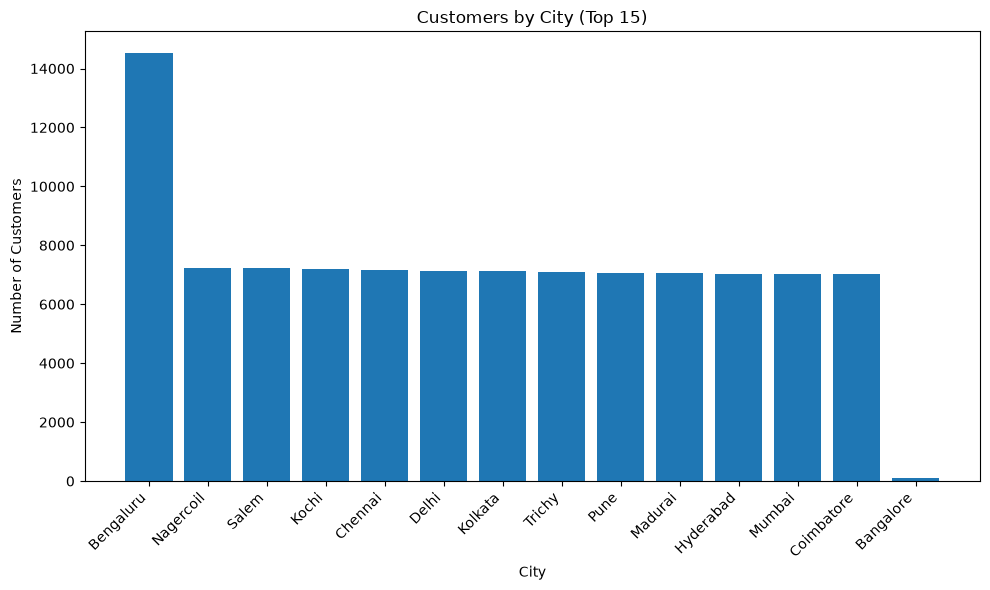

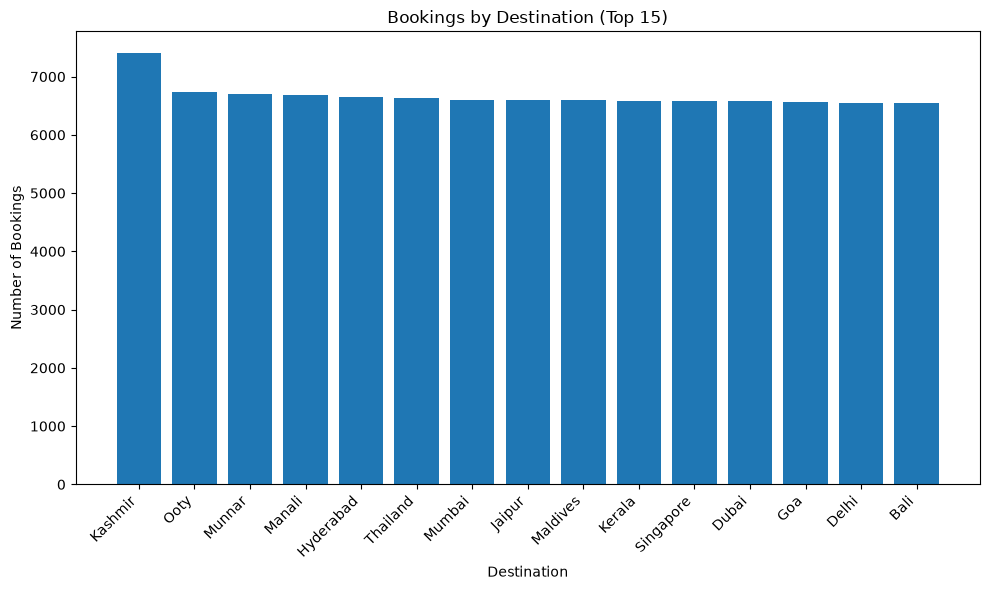

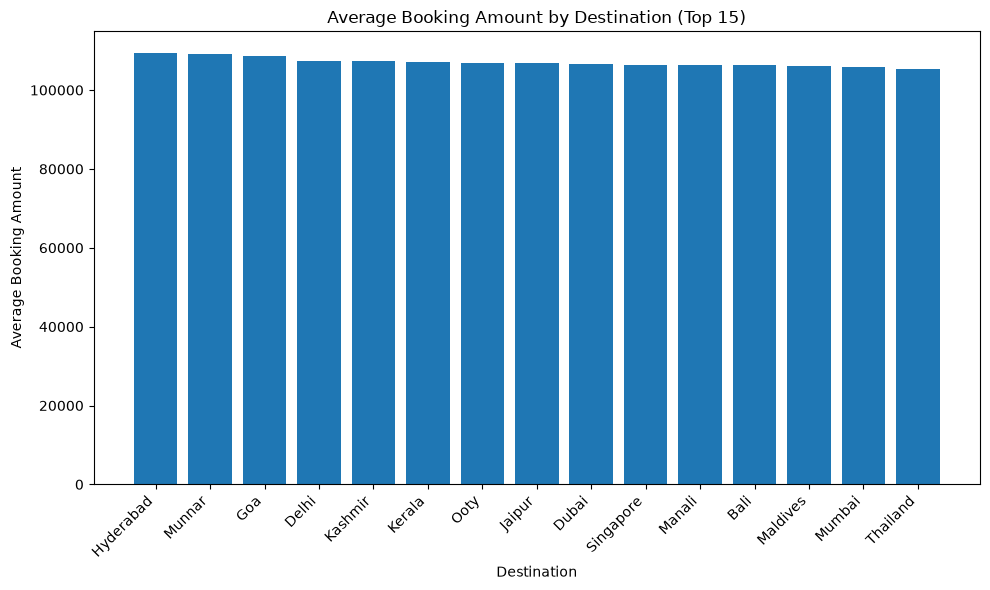

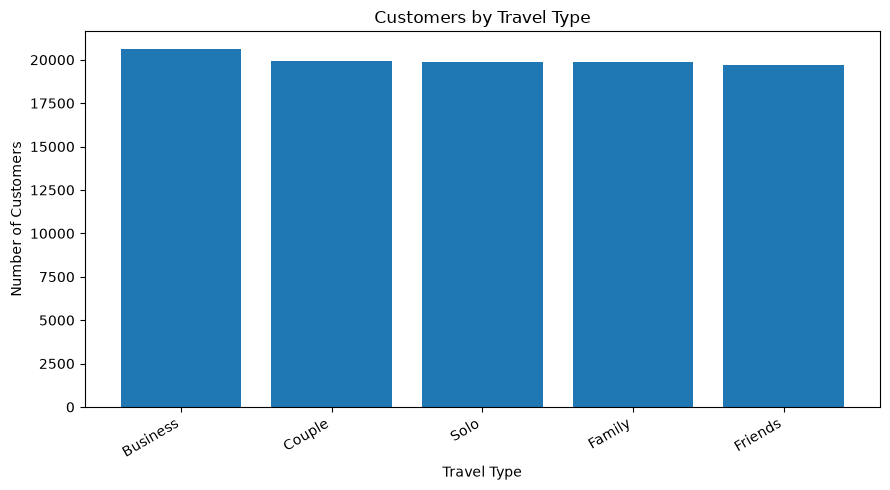

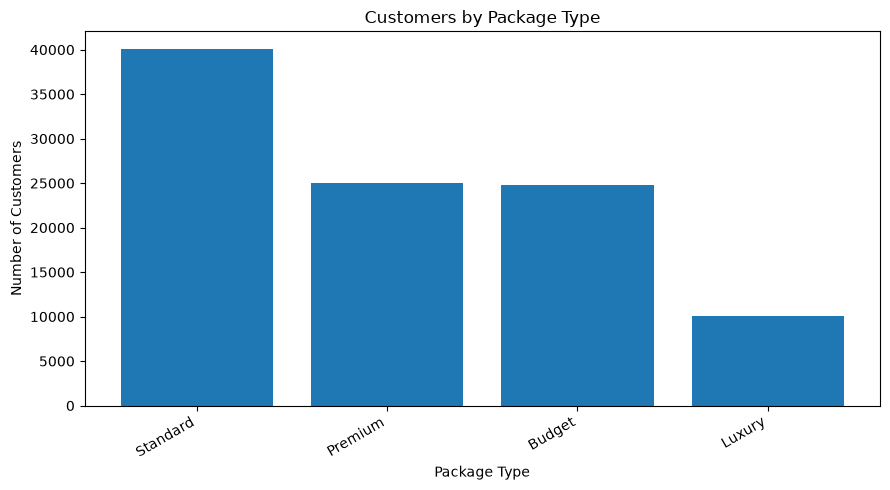

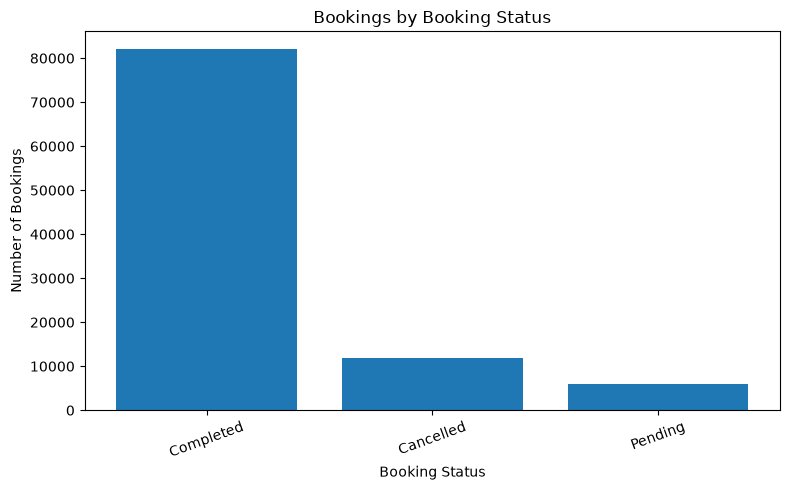

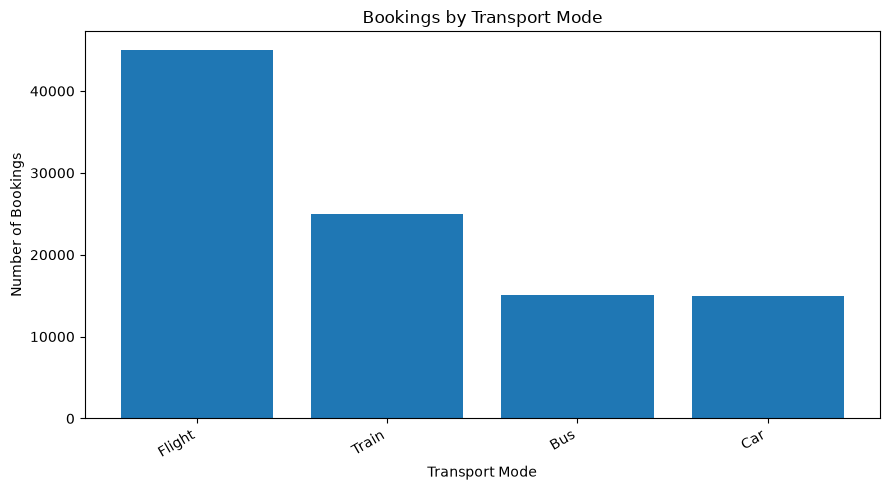

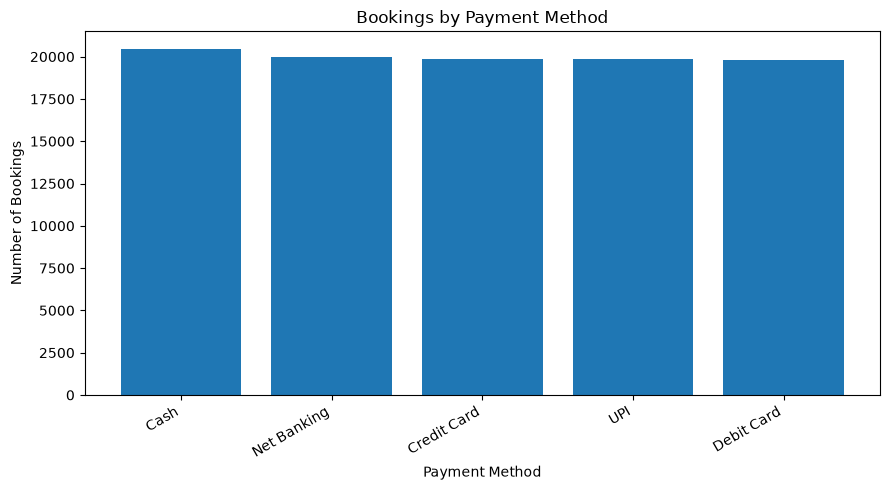

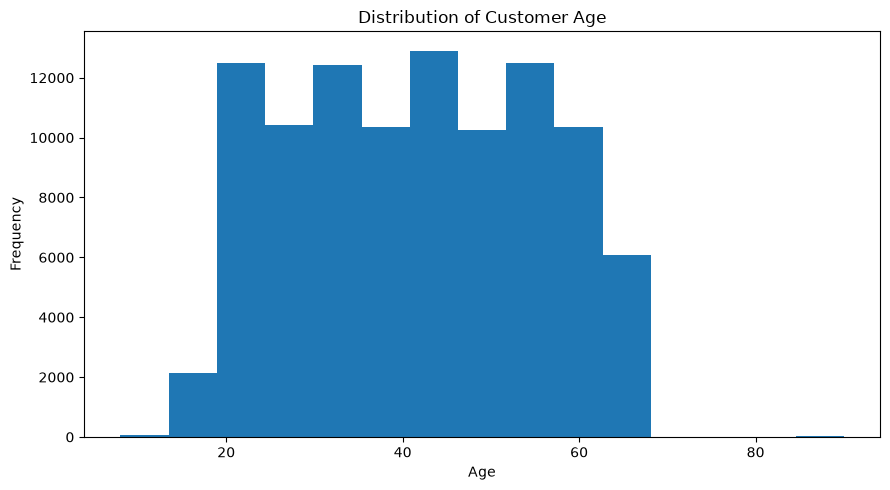

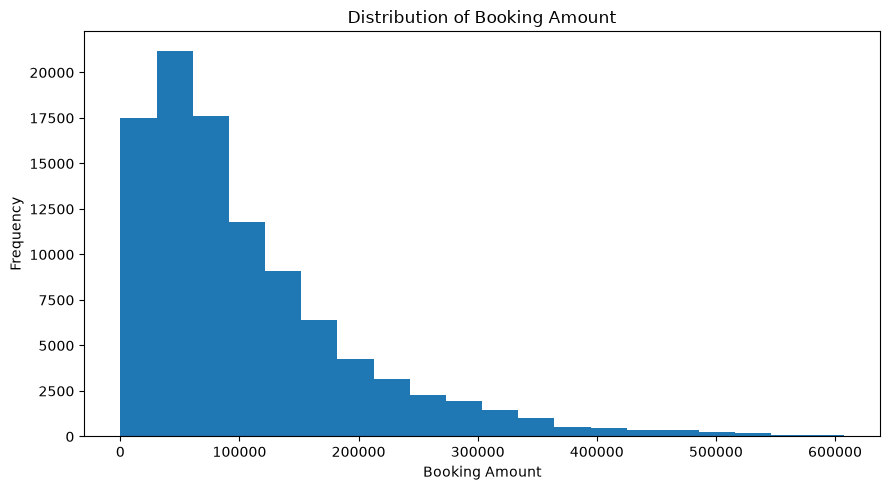

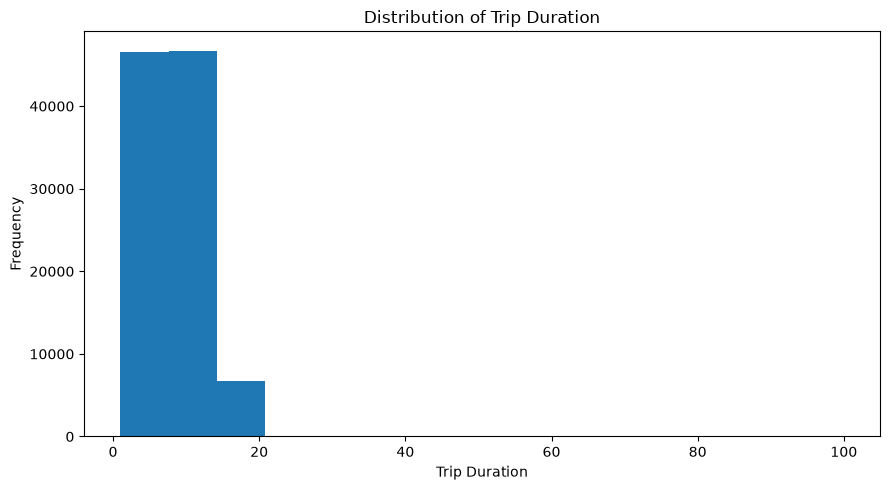

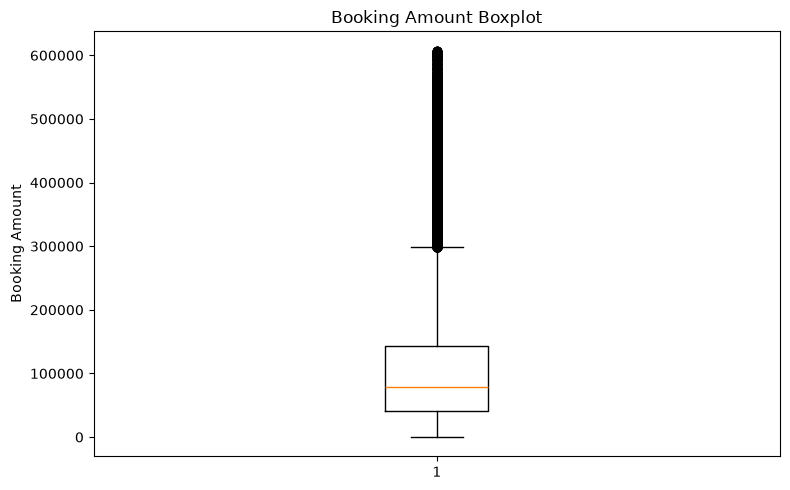

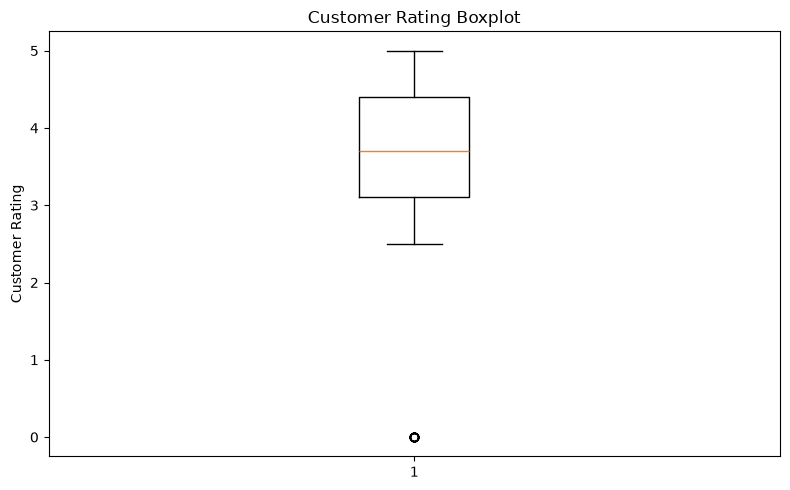

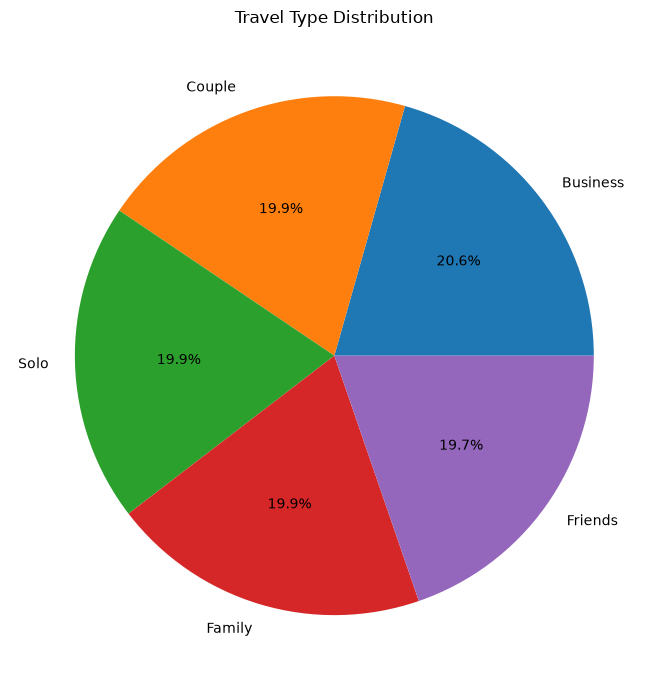

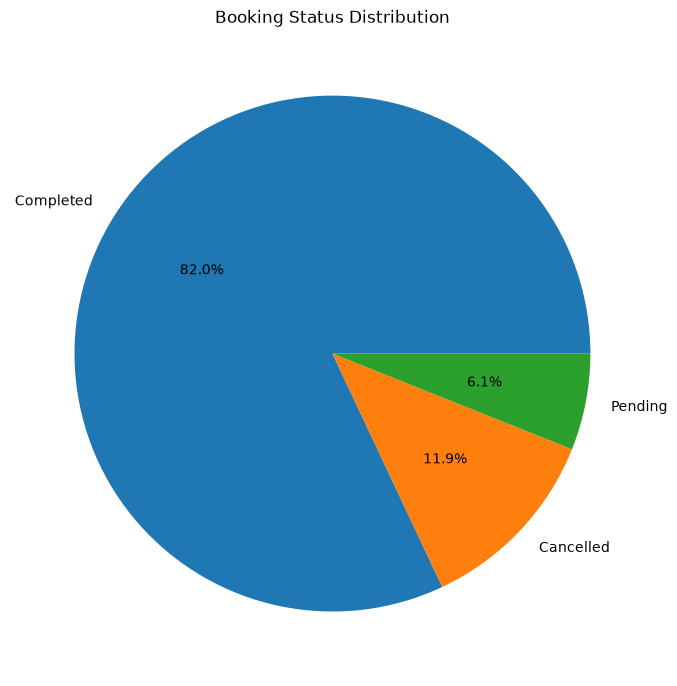

In [15]:
# Q99. Customers by city
city_counts = df.groupby("City")["Customer_ID"].nunique().sort_values(ascending=False).head(15)
plt.figure(figsize=(10, 6))
plt.bar(city_counts.index, city_counts.values)
plt.title("Customers by City (Top 15)")
plt.xlabel("City")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Q100. Bookings by destination
destination_counts = df["Destination"].value_counts().head(15)
plt.figure(figsize=(10, 6))
plt.bar(destination_counts.index, destination_counts.values)
plt.title("Bookings by Destination (Top 15)")
plt.xlabel("Destination")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Q101. Average booking amount by destination
avg_destination_amount = df.groupby("Destination")["Booking_Amount"].mean().sort_values(ascending=False).head(15)
plt.figure(figsize=(10, 6))
plt.bar(avg_destination_amount.index, avg_destination_amount.values)
plt.title("Average Booking Amount by Destination (Top 15)")
plt.xlabel("Destination")
plt.ylabel("Average Booking Amount")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Q102. Customers by travel type
travel_counts = df.groupby("Travel_Type")["Customer_ID"].nunique().sort_values(ascending=False)
plt.figure(figsize=(9, 5))
plt.bar(travel_counts.index, travel_counts.values)
plt.title("Customers by Travel Type")
plt.xlabel("Travel Type")
plt.ylabel("Number of Customers")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# Q103. Customers by package type
package_counts = df.groupby("Package_Type")["Customer_ID"].nunique().sort_values(ascending=False)
plt.figure(figsize=(9, 5))
plt.bar(package_counts.index, package_counts.values)
plt.title("Customers by Package Type")
plt.xlabel("Package Type")
plt.ylabel("Number of Customers")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# Q104. Bookings by booking status
plt.figure(figsize=(8, 5))
plt.bar(booking_status_counts.index, booking_status_counts.values)
plt.title("Bookings by Booking Status")
plt.xlabel("Booking Status")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# Q105. Customers/bookings by transport mode
transport_counts = df["Transport_Mode"].value_counts()
plt.figure(figsize=(9, 5))
plt.bar(transport_counts.index, transport_counts.values)
plt.title("Bookings by Transport Mode")
plt.xlabel("Transport Mode")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# Q106. Customers/bookings by payment method
payment_counts = df["Payment_Method"].value_counts()
plt.figure(figsize=(9, 5))
plt.bar(payment_counts.index, payment_counts.values)
plt.title("Bookings by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# Q107. Histogram of Age
plt.figure(figsize=(9, 5))
plt.hist(df["Age"], bins=15)
plt.title("Distribution of Customer Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Q108. Histogram of Booking Amount
plt.figure(figsize=(9, 5))
plt.hist(df["Booking_Amount"], bins=20)
plt.title("Distribution of Booking Amount")
plt.xlabel("Booking Amount")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Q109. Histogram of Trip Duration
plt.figure(figsize=(9, 5))
plt.hist(df["Trip_Duration"], bins=15)
plt.title("Distribution of Trip Duration")
plt.xlabel("Trip Duration")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Q110. Boxplot for Booking Amount
plt.figure(figsize=(8, 5))
plt.boxplot(df["Booking_Amount"].dropna())
plt.title("Booking Amount Boxplot")
plt.ylabel("Booking Amount")
plt.tight_layout()
plt.show()

# Q111. Boxplot for Customer Rating
plt.figure(figsize=(8, 5))
plt.boxplot(df["Customer_Rating"].dropna())
plt.title("Customer Rating Boxplot")
plt.ylabel("Customer Rating")
plt.tight_layout()
plt.show()

# Q112. Pie chart for travel type distribution
plt.figure(figsize=(7, 7))
travel_pie = df["Travel_Type"].value_counts()
plt.pie(travel_pie.values, labels=travel_pie.index, autopct="%1.1f%%")
plt.title("Travel Type Distribution")
plt.tight_layout()
plt.show()

# Q113. Pie chart for booking status distribution
plt.figure(figsize=(7, 7))
status_pie = df["Booking_Status"].value_counts()
plt.pie(status_pie.values, labels=status_pie.index, autopct="%1.1f%%")
plt.title("Booking Status Distribution")
plt.tight_layout()
plt.show()

## 14. Final Business Analysis — Questions 114–123

In [16]:
# Q114. Most popular destination
most_popular_destination = df["Destination"].value_counts().idxmax()

# Q115. Most popular travel type
most_popular_travel_type = df["Travel_Type"].value_counts().idxmax()

# Q116. Most popular package
most_popular_package = df["Package_Type"].value_counts().idxmax()

# Q117. Destination with highest average booking amount
destination_avg_amount = df.groupby("Destination")["Booking_Amount"].mean()
highest_value_destination = destination_avg_amount.idxmax()

# Q118. Cities contributing the highest number of customers
top_customer_cities = df.groupby("City")["Customer_ID"].nunique().sort_values(ascending=False).head(10)

# Q119. Most commonly used transport mode
most_common_transport = df["Transport_Mode"].value_counts().idxmax()

# Q120. Most commonly used payment method
most_common_payment = df["Payment_Method"].value_counts().idxmax()

print("========== FINAL TRAVEL APP BUSINESS ANALYSIS ==========")

print("\nQ114. Most Popular Destination:", most_popular_destination)
print("Q115. Most Popular Travel Type:", most_popular_travel_type)
print("Q116. Most Popular Package:", most_popular_package)
print("Q117. Highest Average Booking-Value Destination:", highest_value_destination)

print("\nQ118. Top Cities by Customer Count:")
display(top_customer_cities)

print("Q119. Most Common Transport Mode:", most_common_transport)
print("Q120. Most Common Payment Method:", most_common_payment)

# Q121. Loyalty vs non-loyalty comparison
print("\nQ121. Loyalty vs Non-Loyalty Customers:")
display(loyalty_analysis)

# Q122. Completed, cancelled and pending comparison
status_summary = df.groupby("Booking_Status").agg(
    Bookings=("Booking_Status", "size"),
    Percentage=("Booking_Status", lambda x: len(x) / len(df) * 100),
    Avg_Booking_Amount=("Booking_Amount", "mean"),
    Avg_Booking_Count=("Booking_Count", "mean"),
    Avg_Cancellation_Count=("Cancellation_Count", "mean")
).round(2)

print("Q122. Completed vs Cancelled vs Pending:")
display(status_summary)

# Q123. Final report
print("\nQ123. FINAL REPORT")
print("-" * 60)

print(
    f"The travel dataset contains {df['Customer_ID'].nunique():,} unique customers "
    f"across {df['Destination'].nunique():,} destinations."
)

print(
    f"The most popular destination is {most_popular_destination}, "
    f"while {most_popular_travel_type} is the most common travel type."
)

print(
    f"The most popular package is {most_popular_package}. "
    f"The destination with the highest average booking amount is "
    f"{highest_value_destination}."
)

print(
    f"The most commonly used transport mode is {most_common_transport}, "
    f"and the most commonly used payment method is {most_common_payment}."
)

print(
    f"The average booking amount is {df['Booking_Amount'].mean():,.2f}, "
    f"with a total booking value of {df['Booking_Amount'].sum():,.2f}."
)

print(
    f"The average customer rating is {df['Customer_Rating'].mean():.2f}/5 "
    f"and the average hotel rating is {df['Hotel_Rating'].mean():.2f}/5."
)

print(
    "The loyalty table above should be used to compare customer value, "
    "booking frequency and ratings between loyalty and non-loyalty customers."
)

print(
    "The booking-status table above summarizes completed, cancelled and pending "
    "bookings using both volume and percentage."
)

print("\nCleaned dataset saved as: cleaned_travel_dataset.csv")

========== FINAL TRAVEL APP BUSINESS ANALYSIS ==========

Q114. Most Popular Destination: Kashmir
Q115. Most Popular Travel Type: Business
Q116. Most Popular Package: Standard
Q117. Highest Average Booking-Value Destination: Hyderabad

Q118. Top Cities by Customer Count:


City
Bengaluru    14535
Nagercoil     7233
Salem         7214
Kochi         7201
Chennai       7166
Delhi         7128
Kolkata       7128
Trichy        7081
Pune          7070
Madurai       7070
Name: Customer_ID, dtype: int64

Q119. Most Common Transport Mode: Flight
Q120. Most Common Payment Method: Cash

Q121. Loyalty vs Non-Loyalty Customers:


,Customers,Avg_Booking_Amount,Avg_Booking_Count,Avg_Customer_Rating
Loyalty_Member,,,,
No,65177,"107,121.83",4.50,3.75
Yes,34823,"106,876.06",4.51,3.75


Q122. Completed vs Cancelled vs Pending:


,Bookings,Percentage,Avg_Booking_Amount,Avg_Booking_Count,Avg_Cancellation_Count
Booking_Status,,,,,
Cancelled,11947,11.95,"107,293.89",4.51,1.49
Completed,82001,82.00,"106,915.84",4.51,1.51
Pending,6052,6.05,"108,159.12",4.49,1.50



Q123. FINAL REPORT
------------------------------------------------------------
The travel dataset contains 100,000 unique customers across 15 destinations.
The most popular destination is Kashmir, while Business is the most common travel type.
The most popular package is Standard. The destination with the highest average booking amount is Hyderabad.
The most commonly used transport mode is Flight, and the most commonly used payment method is Cash.
The average booking amount is 107,036.24, with a total booking value of 10,703,624,467.00.
The average customer rating is 3.75/5 and the average hotel rating is 3.75/5.
The loyalty table above should be used to compare customer value, booking frequency and ratings between loyalty and non-loyalty customers.
The booking-status table above summarizes completed, cancelled and pending bookings using both volume and percentage.

Cleaned dataset saved as: cleaned_travel_dataset.csv


## Notes for Presentation

The analysis distinguishes **customers** from **bookings** where possible. Customer counts use unique `Customer_ID`, while destination, booking-status, transport and payment counts represent dataset records/bookings.

For invalid numerical values, the cleaning process converts impossible values to missing and then uses the median for numerical missing values. Categorical missing values are filled using the mode. Exact duplicate rows are removed. City and Destination values are standardized for whitespace and capitalization.

The final business conclusions should be taken from the printed values after the notebook is executed on the actual travel dataset.